In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
if_renormalon = False

In [3]:
result_set = {}
accuracies = ["variation"]

for XLL in accuracies:
    result_set[XLL] = pd.read_csv("../result/variation.csv")

Import

In [4]:
import ast
import re

def convert_to_list(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return [float(x) for x in value]

    if pd.isna(value):
        return []

    text = str(value).strip()

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, np.ndarray)):
            return [float(x) for x in parsed]
    except (ValueError, SyntaxError):
        pass

    text = text.strip("[]")
    if not text:
        return []

    parts = [part for part in re.split(r"[\s,]+", text) if part]
    return [float(part) for part in parts]

αs_set_1 = {}
Ω1_set = {}
a_set_2 = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set_1[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    if if_renormalon == False:
        for i in range(cols):
            a_list[i] = params[:,i]
    if if_renormalon == True:
        Ω1_array = params[:,0]
        Ω1_set[XLL] = Ω1_array
        for i in range(cols-1):
            a_list[i] = params[:,i+1]
            
    a_set_2[XLL] = pd.DataFrame(a_list)

    #print(a_list)

In [5]:
a_set_1 = {}
a_set = {}
αs_set = {}
for XLL in accuracies:
    a_list = {}
    a_set_1[XLL] = pd.DataFrame(a_set_2[XLL])
    df_αs = pd.DataFrame({"αs": αs_set_1[XLL]})
    df_total=pd.concat([df_αs,a_set_1[XLL]],axis=1)
    nonzero = df_total[(df_total != -1).all(axis=1)]
    print(len(nonzero))
    αs_set[XLL] = nonzero["αs"]
    for i in range(nonzero.shape[1]-1):
        a_list[i]= np.array(nonzero[i])
    a_set[XLL] = a_list

11000


In [6]:
for XLL in accuracies:
    αs_array = αs_set[XLL]
    print(XLL)
    print(" A: med is",round(np.percentile(a_set[XLL][0],50),3), ", up is",round(np.percentile(a_set[XLL][0],84)-np.percentile(a_set[XLL][0],50),3),", down is",round(np.percentile(a_set[XLL][0],50)-np.percentile(a_set[XLL][0],16),3) )
    print(" a1: med is",round(np.percentile(a_set[XLL][1],50),3),", up is",round(np.percentile(a_set[XLL][1],84)-np.percentile(a_set[XLL][1],50),3),", down is",round(np.percentile(a_set[XLL][1],50)-np.percentile(a_set[XLL][1],16),3) )
    print(" a2: med is",round(np.percentile(a_set[XLL][2],50),3),", up is",round(np.percentile(a_set[XLL][2],84)-np.percentile(a_set[XLL][2],50),3),", down is",round(np.percentile(a_set[XLL][2],50)-np.percentile(a_set[XLL][2],16),3) )
    print(" B: med is",round(np.percentile(a_set[XLL][3],50),3),", up is",round(np.percentile(a_set[XLL][3],84)-np.percentile(a_set[XLL][3],50),3),", down is",round(np.percentile(a_set[XLL][3],50)-np.percentile(a_set[XLL][3],16),3) )
    print()

variation
 A: med is 0.858 , up is 0.004 , down is 0.004
 a1: med is 2.315 , up is 0.274 , down is 0.282
 a2: med is 1.056 , up is 0.025 , down is 0.028
 B: med is 1.238 , up is 0.023 , down is 0.023



In [7]:
medians = [0.858,2.31,1.059,1.238]

for XLL in accuracies:
    αs_array = αs_set[XLL]
    print(XLL)
    print(" A: med is",round(medians[0],3), ", up is",round(np.percentile(a_set[XLL][0],84)-medians[0],3),", down is",round(medians[0]-np.percentile(a_set[XLL][0],16),3) )
    print(" a1: med is",round(np.percentile(medians[1],50),3),", up is",round(np.percentile(a_set[XLL][1],84)-np.percentile(medians[1],50),3),", down is",round(np.percentile(medians[1],50)-np.percentile(a_set[XLL][1],16),3) )
    print(" a2: med is",round(np.percentile(medians[2],50),3),", up is",round(np.percentile(a_set[XLL][2],84)-np.percentile(medians[2],50),3),", down is",round(np.percentile(medians[2],50)-np.percentile(a_set[XLL][2],16),3) )
    print(" B: med is",round(np.percentile(medians[3],50),3),", up is",round(np.percentile(a_set[XLL][3],84)-np.percentile(medians[3],50),3),", down is",round(np.percentile(medians[3],50)-np.percentile(a_set[XLL][3],16),3) )
    print()

variation
 A: med is 0.858 , up is 0.004 , down is 0.004
 a1: med is 2.31 , up is 0.279 , down is 0.278
 a2: med is 1.059 , up is 0.022 , down is 0.031
 B: med is 1.238 , up is 0.023 , down is 0.023



Correlation

In [8]:
data = {}
mean = {}
df_set = {}
cov_matrix = {}
std_devs = {}
corr_matrix = {}

for XLL in accuracies:
    
    data[XLL]={}
    mean[XLL]={}

    a_list = a_set[XLL]

    l=len(a_list)
    for i in range(l):
        data[XLL][i] = a_list[i]
        mean[XLL][i] = np.mean(data[XLL][i])

    df_set[XLL]=pd.DataFrame(data[XLL])
    X = df_set[XLL].values

    cov_matrix[XLL] = np.cov(X, rowvar=False)
    std_devs[XLL] = np.sqrt(np.diag(cov_matrix[XLL]))
    corr_matrix[XLL] = cov_matrix[XLL] / np.outer(std_devs[XLL], std_devs[XLL])

for XLL in accuracies:
    display(XLL)
    display("mean:", mean[XLL])
    display("covariance matrix:", corr_matrix[XLL])
    display(df_set[XLL])

'variation'

'mean:'

{0: np.float64(0.8580369574545456),
 1: np.float64(2.3080336543636366),
 2: np.float64(1.0543434622727272),
 3: np.float64(1.238189620090909)}

'covariance matrix:'

array([[ 1.        , -0.00642812, -0.0019416 ,  0.0051213 ],
       [-0.00642812,  1.        , -0.01033316, -0.01222166],
       [-0.0019416 , -0.01033316,  1.        , -0.00922901],
       [ 0.0051213 , -0.01222166, -0.00922901,  1.        ]])

,0,1,2,3
0,0.864379,1.918704,1.044826,1.263467
1,0.856614,2.566564,1.093830,1.215211
2,0.857179,2.187578,1.087581,1.292772
3,0.856931,2.117534,1.084973,1.212032
4,0.864103,1.987256,1.087761,1.201598
...,...,...,...,...
10995,0.864274,2.482065,1.049394,1.233039
10996,0.860674,1.958031,1.014882,1.251525
10997,0.857667,1.749717,1.073382,1.239370
10998,0.857826,2.318423,1.088720,1.233165


Plot

In [9]:
scale_68 = np.sqrt(2.279)
scale_95 = np.sqrt(5.991)

from matplotlib.patches import Ellipse
def draw_ellipse(mean, cov, scale, ax, **kwargs):

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    eigenvalues = 2.0 * scale * np.sqrt(eigenvalues)
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    ell = Ellipse(xy=mean, width=eigenvalues[0], height=eigenvalues[1], angle=angle, **kwargs)
    
    ax.add_artist(ell)

In [10]:
data_set = {}

for XLL in accuracies:
    data_set[XLL] = df_set[XLL].copy()
    l = df_set[XLL].shape[0]
    XLL_series = pd.Series([XLL]*l)
    data_set[XLL]["XLL"] =  XLL_series

data_combined = pd.DataFrame()
df_c = pd.DataFrame()
for XLL in accuracies:
    data_combined = pd.concat([data_combined,data_set[XLL]],ignore_index=True)
    df_c = pd.concat([data_combined,df_set[XLL]],ignore_index=True)
#display(data_set['bbstar_fit_cut'][3])

In [11]:
# Plot settings (edit this cell only)
PLOT_PARAM_LABELS = [r"$\mathrm{A}$", r"$\mathrm{a}_1$", r"$\mathrm{a}_2$", r"$\mathrm{B}$"]
PLOT_PARAM_INDICES = [0, 1, 2, 3]

# Chi2 cuts: set CHI2_LEVELS = None to use automatic quantile cuts
chi2_base = 1.38
ratios = [1.02, 1.1, 1.20, 1.50, 2]
CHI2_LEVELS = [chi2_base * r for r in ratios]
CHI2_N_CUTS = 5

# Fill style: discrete red-orange colors by level (opaque)
# Order is inner -> outer (small chi2 cut -> large chi2 cut)
CHI2_LEVEL_COLORS = [
    "#8c0000",  # dark red
    "#b30000",  # red
    "#d7301f",  # red-orange
    "#f16913",  # orange-red
    "#ff8c00",  # orange
]
CHI2_LEVEL_ALPHAS = [1.00, 1.00, 1.00, 1.00, 1.00]

# KDE / contour behavior
CONTOUR_MASS = 0.9
PAIR_BW_SCALE = 1.3
DIAG_BW_ADJUST = 1.0
MIN_POINTS_KDE2D = 10
MIN_POINTS_PER_CUT = 2
GRID_SIZE = 180
PAD_FRAC = 0.10
RANGE_PAD_FRAC = 0.15
NUM_VAR_TICKS = 5
TICK_SIG_DIGITS = 3

# Figure/layout
FIG_SIZE = (11, 10)
FONT_SIZE = 13
TICK_SIZE = 11
SEPARATOR_COLOR = "black"
SEPARATOR_WIDTH = 0.70
FILL_ZORDER = 1
LINE_ZORDER = 5
LEGEND_MAX_COLS = 3
OUTPUT_PREFIX = "chi2_cut_contours"






In [12]:
from IPython.display import display

PARAM_NAMES = ["A", "a1", "a2", "B"]


def build_param_chi2_df(results_df):
    params = np.array(results_df["params"].apply(convert_to_list).to_list(), dtype=float)
    chi2 = pd.to_numeric(results_df["chi2/dof"], errors="coerce").to_numpy()
    keep = np.isfinite(chi2) & np.all(np.isfinite(params[:, :4]), axis=1)

    out = pd.DataFrame(params[keep, :4], columns=PLOT_PARAM_INDICES)
    out["chi2/dof"] = chi2[keep]
    return out


def choose_chi2_cuts(chi2_values, n_cuts=CHI2_N_CUTS):
    qmin = globals().get("CHI2_QUANTILE_MIN", 0.30)
    qmax = globals().get("CHI2_QUANTILE_MAX", 0.98)
    quantiles = np.linspace(qmin, qmax, n_cuts)
    cuts = np.quantile(chi2_values, quantiles)
    return np.unique(np.round(cuts, 6)).tolist()


def central68_errors(base_df):
    rows = []
    for idx, name in zip(PLOT_PARAM_INDICES, PARAM_NAMES):
        vals = pd.to_numeric(base_df[idx], errors="coerce").to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]

        if vals.size == 0:
            p16 = p50 = p84 = np.nan
        else:
            p16, p50, p84 = np.percentile(vals, [16, 50, 84])

        rows.append({
            "parameter": name,
            "central": p50,
            "down": p50 - p16,
            "up": p84 - p50,
        })

    return pd.DataFrame(rows)


def prepare_chi2_cut_data(results_df, label, chi2_cuts=CHI2_LEVELS, n_cuts=CHI2_N_CUTS):
    df_plot = build_param_chi2_df(results_df)
    if df_plot.empty:
        print(f"{label}: no valid rows.")
        return None

    if chi2_cuts is None:
        cuts = choose_chi2_cuts(df_plot["chi2/dof"].to_numpy(), n_cuts=n_cuts)
    else:
        cuts = sorted(set(float(c) for c in chi2_cuts))

    valid_cuts = []
    subsets = []
    prev_n = -1

    for cut in cuts:
        sub = df_plot[df_plot["chi2/dof"] <= cut].copy()
        n = len(sub)
        if n > MIN_POINTS_PER_CUT and n != prev_n:
            valid_cuts.append(float(cut))
            subsets.append(sub)
            prev_n = n

    if len(valid_cuts) == 0:
        print(f"{label}: no usable chi2 cuts.")
        return None

    counts_df = pd.DataFrame({
        "chi2_cut": valid_cuts,
        "n_rows": [len(sub) for sub in subsets],
    })

    print(f"{label}:")
    display(counts_df)

    # These are computed directly from chi2-cut subsets (independent of CONTOUR_MASS).
    correlations = []
    central68_tables = []

    for cut, sub in zip(valid_cuts, subsets):
        base = sub[PLOT_PARAM_INDICES]

        corr = base.corr()
        corr.index = PARAM_NAMES
        corr.columns = PARAM_NAMES
        correlations.append(corr)

        central68 = central68_errors(base)
        central68_tables.append(central68)

        print(f"chi2/dof <= {cut:.3f}, n={len(sub)}:")
        
        display(corr.round(2))

        display(central68.round(3))

    return {
        "label": label,
        "df_plot": df_plot,
        "cuts": valid_cuts,
        "subsets": subsets,
        "counts": counts_df,
        "correlations": correlations,
        "central68": central68_tables,
    }


PREPARED_CHI2_DATA = {}

for XLL in accuracies:
    prepared = prepare_chi2_cut_data(result_set[XLL], label=XLL)
    if prepared is not None:
        PREPARED_CHI2_DATA[XLL] = prepared

if not PREPARED_CHI2_DATA:
    print("No prepared chi2-cut data found. Check CHI2_LEVELS or input data.")

variation:


,chi2_cut,n_rows
0,1.4076,150
1,1.5180,1191
2,1.6560,2290
3,2.0700,4246
4,2.7600,6002


chi2/dof <= 1.408, n=150:


,A,a1,a2,B
A,1.00,-0.54,-0.10,-0.38
a1,-0.54,1.00,0.29,-0.05
a2,-0.10,0.29,1.00,0.44
B,-0.38,-0.05,0.44,1.00


,parameter,central,down,up
0,A,0.858,0.003,0.002
1,a1,2.309,0.023,0.023
2,a2,1.058,0.008,0.008
3,B,1.238,0.011,0.011


...

,A,a1,a2,B
A,1.0,-0.20,-0.00,-0.00
a1,-0.2,1.00,0.27,-0.19
a2,-0.0,0.27,1.00,0.04
B,-0.0,-0.19,0.04,1.00


,parameter,central,down,up
0,A,0.858,0.004,0.004
1,a1,2.311,0.112,0.107
2,a2,1.056,0.024,0.024
3,B,1.238,0.022,0.022


chi2/dof <= 2.760, n=6002:


,A,a1,a2,B
A,1.00,-0.12,0.00,0.01
a1,-0.12,1.00,0.17,-0.13
a2,0.00,0.17,1.00,0.01
B,0.01,-0.13,0.01,1.00


,parameter,central,down,up
0,A,0.858,0.004,0.004
1,a1,2.313,0.154,0.150
2,a2,1.056,0.026,0.024
3,B,1.238,0.023,0.022


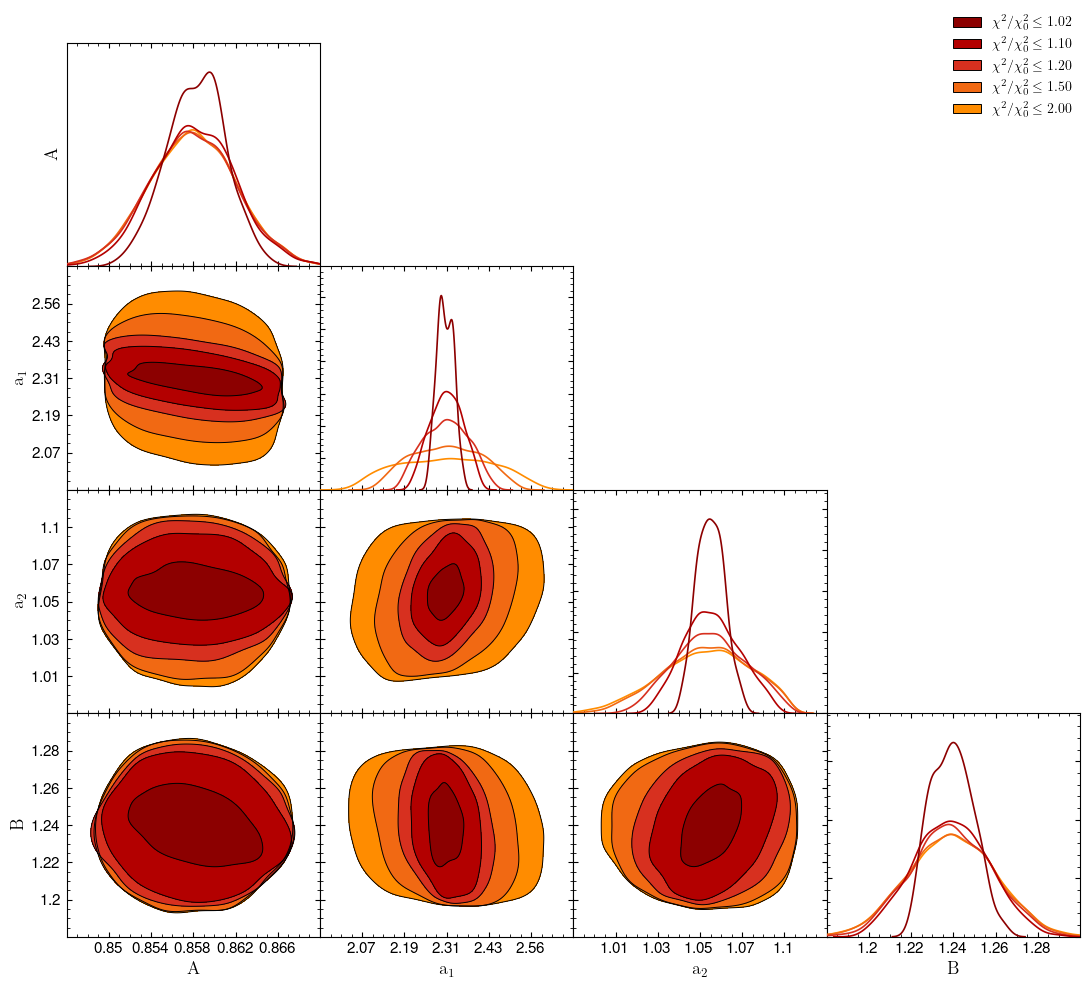

In [13]:
from scipy.stats import gaussian_kde
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

mpl.rcParams["path.simplify"] = False


def chi2_colors(n_levels):
    # One discrete color per level (no interpolation in plot drawing).
    base = list(CHI2_LEVEL_COLORS)
    if len(base) == 0:
        raise ValueError("CHI2_LEVEL_COLORS is empty.")
    if len(base) >= n_levels:
        return base[:n_levels]
    idx = np.linspace(0, len(base) - 1, n_levels).round().astype(int)
    return [base[i] for i in idx]


def chi2_level_alphas(n_levels):
    base = list(CHI2_LEVEL_ALPHAS)
    if len(base) == 0:
        raise ValueError("CHI2_LEVEL_ALPHAS is empty.")
    if len(base) >= n_levels:
        return base[:n_levels]
    idx = np.linspace(0, len(base) - 1, n_levels).round().astype(int)
    return [base[i] for i in idx]


def _single_kde_level(z, enclosed_frac=CONTOUR_MASS):
    z_sorted = np.sort(z.ravel())[::-1]
    cdf = np.cumsum(z_sorted)
    cdf /= cdf[-1]
    idx = np.searchsorted(cdf, enclosed_frac)
    idx = min(idx, len(z_sorted) - 1)
    return z_sorted[idx]


def _pad_limits(lo, hi, frac=RANGE_PAD_FRAC):
    span = hi - lo
    if span <= 0:
        scale = max(abs(lo), 1.0)
        span = 1e-3 * scale
    pad = frac * span
    return lo - pad, hi + pad


def _format_sig(x, sig=3):
    if not np.isfinite(x):
        return ""
    if x == 0:
        return "0"
    return f"{x:.{sig}g}"


def _interior_ticks(lo, hi, n_ticks=5):
    # Strictly interior and evenly spaced ticks (never on boundaries).
    if hi <= lo:
        return np.array([])
    n = max(2, int(n_ticks))
    return np.linspace(lo, hi, n + 2)[1:-1]


def draw_pair_region(ax, x, y, color, fill_alpha, erase_first=False, contour_mass=CONTOUR_MASS, bw_scale=PAIR_BW_SCALE):
    if len(x) < MIN_POINTS_KDE2D:
        return False, None

    xy = np.vstack([x, y])
    try:
        kde = gaussian_kde(xy, bw_method=lambda s: s.scotts_factor() * bw_scale)
    except np.linalg.LinAlgError:
        return False, None

    xmin, xmax = np.min(x), np.max(x)
    ymin, ymax = np.min(y), np.max(y)
    dx = (xmax - xmin) if xmax > xmin else 1e-3
    dy = (ymax - ymin) if ymax > ymin else 1e-3

    xx, yy = np.meshgrid(
        np.linspace(xmin - PAD_FRAC * dx, xmax + PAD_FRAC * dx, GRID_SIZE),
        np.linspace(ymin - PAD_FRAC * dy, ymax + PAD_FRAC * dy, GRID_SIZE),
    )
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    level = _single_kde_level(zz, enclosed_frac=contour_mass)
    zmax = float(np.max(zz))
    if (not np.isfinite(level)) or (level >= zmax):
        return False, None

    mask = zz >= level
    if not np.any(mask):
        return False, None

    bounds = (
        float(np.min(xx[mask])),
        float(np.max(xx[mask])),
        float(np.min(yy[mask])),
        float(np.max(yy[mask])),
    )

    if erase_first:
        ax.contourf(
            xx,
            yy,
            zz,
            levels=[level, zmax],
            colors=["white"],
            antialiased=False,
            zorder=FILL_ZORDER,
        )

    ax.contourf(
        xx,
        yy,
        zz,
        levels=[level, zmax],
        colors=[color],
        alpha=fill_alpha,
        antialiased=False,
        zorder=FILL_ZORDER,
    )
    ax.contour(
        xx,
        yy,
        zz,
        levels=[level],
        colors=[SEPARATOR_COLOR],
        linewidths=SEPARATOR_WIDTH,
        zorder=LINE_ZORDER,
    )
    return True, bounds


def plot_chi2_cut_corner(prepared, output_prefix=OUTPUT_PREFIX):
    label = prepared["label"]
    valid_cuts = prepared["cuts"]
    subsets = prepared["subsets"]

    colors = chi2_colors(len(valid_cuts))
    alphas = chi2_level_alphas(len(valid_cuts))
    draw_order = list(range(len(valid_cuts) - 1, -1, -1))

    fig, axes = plt.subplots(4, 4, figsize=FIG_SIZE, facecolor="white")
    outer = subsets[-1]

    # Gather outermost contour bounds across all off-diagonal panels.
    var_bounds = {p: [np.inf, -np.inf] for p in PLOT_PARAM_INDICES}
    diag_y_top = {p: 1.0 for p in PLOT_PARAM_INDICES}

    for i in range(4):
        for j in range(4):
            ax = axes[i, j]
            ax.set_facecolor("white")

            if i < j:
                ax.axis("off")
                continue

            if i == j:
                for idx in draw_order:
                    color = colors[idx]
                    sub = subsets[idx]
                    vals = sub[j].to_numpy()
                    if len(vals) >= 2:
                        sns.kdeplot(
                            vals,
                            ax=ax,
                            color=color,
                            fill=False,
                            linewidth=max(1.2, SEPARATOR_WIDTH),
                            bw_adjust=DIAG_BW_ADJUST,
                            legend=False,
                            zorder=LINE_ZORDER,
                        )
                y_top = float(ax.dataLim.y1) if np.isfinite(ax.dataLim.y1) and ax.dataLim.y1 > 0 else 1.0
                diag_y_top[j] = max(diag_y_top[j], y_top)
                ax.set_ylabel("")
            else:
                any_drawn = False
                outer_bounds = None

                for order_pos, idx in enumerate(draw_order):
                    color = colors[idx]
                    level_alpha = alphas[idx]
                    sub = subsets[idx]
                    x = sub[j].to_numpy()
                    y = sub[i].to_numpy()

                    drawn, bounds = draw_pair_region(
                        ax,
                        x,
                        y,
                        color,
                        level_alpha,
                        erase_first=(order_pos > 0),
                        contour_mass=CONTOUR_MASS,
                        bw_scale=PAIR_BW_SCALE,
                    )
                    any_drawn = any_drawn or drawn
                    if order_pos == 0 and drawn and bounds is not None:
                        outer_bounds = bounds

                if not any_drawn:
                    sub = subsets[-1]
                    ax.scatter(sub[j], sub[i], s=5, color=colors[-1], alpha=alphas[-1], linewidths=0)

                if outer_bounds is None:
                    x_lo = float(np.min(outer[j].to_numpy()))
                    x_hi = float(np.max(outer[j].to_numpy()))
                    y_lo = float(np.min(outer[i].to_numpy()))
                    y_hi = float(np.max(outer[i].to_numpy()))
                else:
                    x_lo, x_hi, y_lo, y_hi = outer_bounds

                var_bounds[j][0] = min(var_bounds[j][0], x_lo)
                var_bounds[j][1] = max(var_bounds[j][1], x_hi)
                var_bounds[i][0] = min(var_bounds[i][0], y_lo)
                var_bounds[i][1] = max(var_bounds[i][1], y_hi)

            ax.minorticks_on()
            ax.tick_params(direction="in", top=True, right=True, labelsize=TICK_SIZE)
            ax.tick_params(axis="both", which="minor", direction="in", top=True, right=True, length=2)
            ax.tick_params(axis="x", labelbottom=True)

    # Shared limits and interior ticks per variable.
    n_ticks = int(globals().get("NUM_VAR_TICKS", 5))
    sig_digits = int(globals().get("TICK_SIG_DIGITS", 3))
    fmt = FuncFormatter(lambda x, pos: _format_sig(x, sig=sig_digits))

    var_limits = {}
    var_ticks = {}
    for p in PLOT_PARAM_INDICES:
        lo, hi = var_bounds[p]
        if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (hi <= lo):
            vals = outer[p].to_numpy()
            lo = float(np.min(vals))
            hi = float(np.max(vals))
        lo_p, hi_p = _pad_limits(lo, hi, frac=RANGE_PAD_FRAC)
        var_limits[p] = (lo_p, hi_p)
        var_ticks[p] = _interior_ticks(lo_p, hi_p, n_ticks=n_ticks)

    for i in range(4):
        for j in range(4):
            if i < j:
                continue
            ax = axes[i, j]
            ax.set_xlim(var_limits[j])
            ax.set_xticks(var_ticks[j])
            ax.xaxis.set_major_formatter(fmt)

            if i == j:
                ax.set_ylim(0.0, diag_y_top[i] * (1.0 + RANGE_PAD_FRAC))
                if i == 0:
                    ax.set_yticks([])
            else:
                ax.set_ylim(var_limits[i])
                ax.set_yticks(var_ticks[i])
                ax.yaxis.set_major_formatter(fmt)

            if j > 0:
                ax.set_yticklabels([])

    for j, name in enumerate(PLOT_PARAM_LABELS):
        axes[3, j].set_xlabel(name, fontsize=FONT_SIZE)
    for i, name in enumerate(PLOT_PARAM_LABELS):
        axes[i, 0].set_ylabel(name, fontsize=FONT_SIZE)

    handles = [
        Patch(
            facecolor=color,
            edgecolor=SEPARATOR_COLOR,
            linewidth=SEPARATOR_WIDTH,
            alpha=level_alpha,
            label=fr"$\chi^2/\chi_0^2 \leq {ratios[k]:.2f}$",
        )
        for k, (color, level_alpha) in enumerate(zip(colors, alphas))
    ]
    fig.legend(
        handles=handles,
        loc="upper right",
        ncol=1,
        frameon=False,
        bbox_to_anchor=(0.99, 0.99),
    )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95)
    plt.show()

    safe_label = str(label).replace(" ", "_")
    fig.savefig(f"{output_prefix}_{safe_label}.pdf", bbox_inches="tight")

for XLL in accuracies:
    if XLL in PREPARED_CHI2_DATA:
        plot_chi2_cut_corner(PREPARED_CHI2_DATA[XLL], output_prefix=OUTPUT_PREFIX)

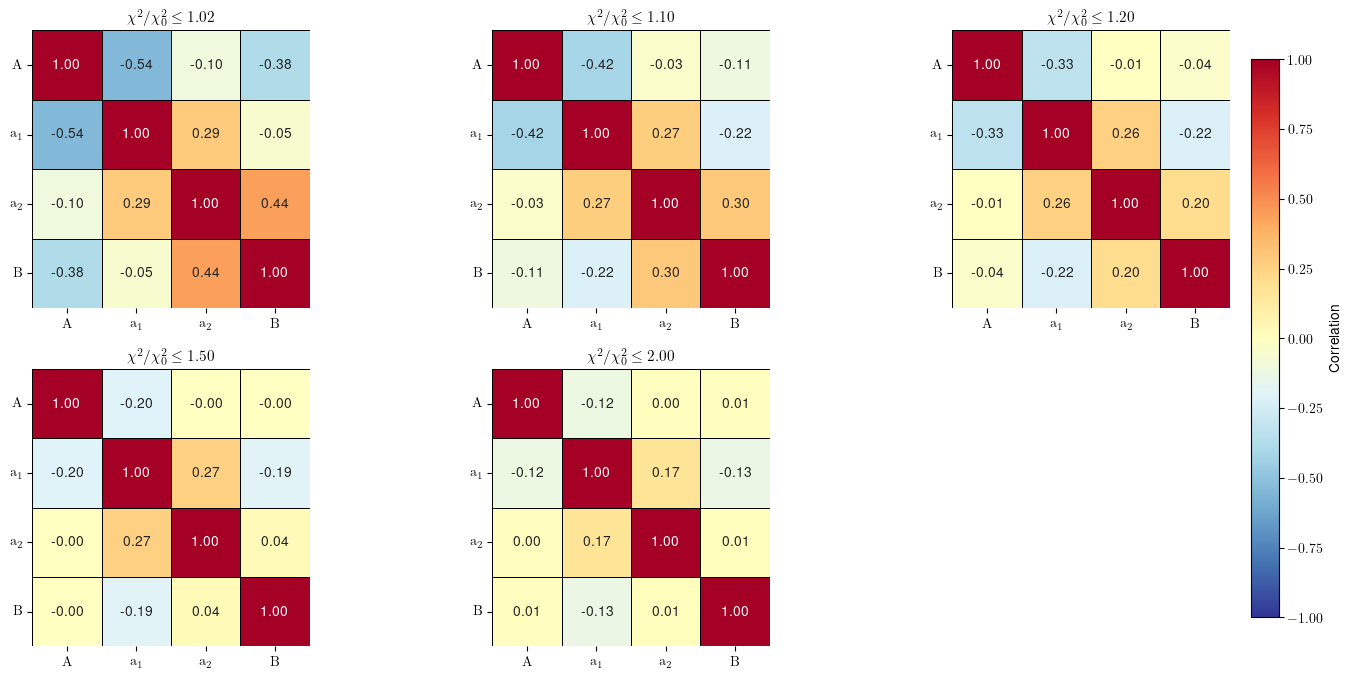

Saved: correlation_matrices_variation.pdf


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation-matrix plot settings
CORR_OUTPUT_PREFIX = "correlation_matrices"
CORR_N_SUBPLOTS = 5
CORR_N_ROWS = 2
CORR_FIGSIZE = (18, 8)
CORR_CMAP = "RdYlBu_r"
CORR_VMIN, CORR_VMAX = -1.0, 1.0
CORR_ANNOT = True
CORR_ANNOT_FMT = ".2f"
CORR_LINEWIDTH = 0.5
CORR_WSPACE = 0.04
CORR_HSPACE = 0.20
CORR_CBAR_FRACTION = 0.020
CORR_CBAR_PAD = 0.040
CORR_TITLE_SIZE = 13
CORR_TICK_SIZE = 12
CORR_ANNOT_SIZE = 11
CORR_CBAR_LABEL_SIZE = 12
CORR_CBAR_TICK_SIZE = 11


def plot_correlation_matrices(prepared, output_prefix=CORR_OUTPUT_PREFIX):
    label = prepared["label"]
    corrs = prepared.get("correlations", [])
    cuts = prepared.get("cuts", [])

    if len(corrs) == 0:
        print(f"{label}: no correlations to plot.")
        return

    n_panels = min(int(CORR_N_SUBPLOTS), len(corrs))
    n_rows = max(1, int(CORR_N_ROWS))
    n_cols = int(np.ceil(n_panels / n_rows))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=CORR_FIGSIZE, constrained_layout=False)
    axes = np.atleast_1d(axes).ravel()
    fig.subplots_adjust(wspace=CORR_WSPACE, hspace=CORR_HSPACE)

    for k, ax in enumerate(axes):
        if k >= n_panels:
            ax.axis("off")
            continue

        corr = corrs[k]
        if isinstance(corr, pd.DataFrame):
            mat = corr.to_numpy(dtype=float)
        else:
            mat = np.asarray(corr, dtype=float)

        sns.heatmap(
            mat,
            ax=ax,
            cmap=CORR_CMAP,
            vmin=CORR_VMIN,
            vmax=CORR_VMAX,
            square=True,
            cbar=False,
            annot=CORR_ANNOT,
            fmt=CORR_ANNOT_FMT,
            xticklabels=PLOT_PARAM_LABELS,
            yticklabels=PLOT_PARAM_LABELS,
            linewidths=CORR_LINEWIDTH,
            linecolor="black",
            annot_kws={"size": CORR_ANNOT_SIZE},
        )

        if "ratios" in globals() and k < len(ratios):
            title = fr"$\chi^2/\chi_0^2 \leq {ratios[k]:.2f}$"
        elif k < len(cuts):
            title = fr"$\chi^2/\mathrm{{dof}} \leq {cuts[k]:.3f}$"
        else:
            title = f"cut {k+1}"

        ax.set_title(title, fontsize=CORR_TITLE_SIZE)
        ax.tick_params(axis="x", rotation=0, labelsize=CORR_TICK_SIZE)
        ax.tick_params(axis="y", rotation=0, labelsize=CORR_TICK_SIZE)

    mappable = plt.cm.ScalarMappable(cmap=CORR_CMAP, norm=plt.Normalize(vmin=CORR_VMIN, vmax=CORR_VMAX))
    mappable.set_array([])
    cbar = fig.colorbar(mappable, ax=axes.tolist(), fraction=CORR_CBAR_FRACTION, pad=CORR_CBAR_PAD)
    cbar.set_label("Correlation", fontsize=CORR_CBAR_LABEL_SIZE)
    cbar.ax.tick_params(labelsize=CORR_CBAR_TICK_SIZE)

    safe_label = str(label).replace(" ", "_")
    save_path = f"{output_prefix}_{safe_label}.pdf"
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


for XLL in accuracies:
    if XLL in PREPARED_CHI2_DATA:
        plot_correlation_matrices(PREPARED_CHI2_DATA[XLL])

